In [35]:
from warnings import simplefilter
simplefilter(action='ignore')
import numpy as np 
import pandas as pd
import missingno as msno

In [36]:
df = pd.read_parquet('house_model_base.parquet')

In [37]:
display(df.info(), df.columns, df.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 8572 entries, 0 to 8571
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CAND_ID                              8572 non-null   str    
 1   CYCLE                                8572 non-null   int64  
 2   STATE                                8572 non-null   str    
 3   DISTRICT                             8572 non-null   int64  
 4   CAND_NAME_FIRST                      8572 non-null   str    
 5   CAND_NAME_LAST                       8572 non-null   str    
 6   CAND_NAME                            8572 non-null   str    
 7   RESULTS_PARTY                        8572 non-null   str    
 8   CAND_PTY_AFFILIATION                 8569 non-null   str    
 9   CAND_ICI                             8568 non-null   str    
 10  OUTCOME                              8572 non-null   int64  
 11  UNOPPOSED                            8572

None

Index(['CAND_ID', 'CYCLE', 'STATE', 'DISTRICT', 'CAND_NAME_FIRST',
       'CAND_NAME_LAST', 'CAND_NAME', 'RESULTS_PARTY', 'CAND_PTY_AFFILIATION',
       'CAND_ICI', 'OUTCOME', 'UNOPPOSED', 'VOTES', 'VOTE_SHARE',
       'TTL_RECEIPTS', 'TRANS_FROM_AUTH', 'TTL_DISB', 'TRANS_TO_AUTH',
       'COH_COP', 'CAND_CONTRIB', 'CAND_LOANS', 'TTL_INDIV_CONTRIB',
       'OTHER_POL_CMTE_CONTRIB', 'POL_PTY_CONTRIB', 'ITEMIZED_INDIV_AMOUNT',
       'ITEMIZED_INDIV_MISSING', 'ITEMIZED_INDIV_AMOUNT_MODEL',
       'ITEMIZED_INDIV_SHARE_OF_INDIV', 'ITEMIZED_INDIV_SHARE_OF_INDIV_MODEL',
       'IND_EXP_SUPPORT', 'IND_EXP_OPPOSE', 'COMM_SUPPORT', 'COMM_OPPOSE',
       'PARTY_COORD_EXP'],
      dtype='str')

,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,ITEMIZED_INDIV_AMOUNT,ITEMIZED_INDIV_MISSING,ITEMIZED_INDIV_AMOUNT_MODEL,ITEMIZED_INDIV_SHARE_OF_INDIV,ITEMIZED_INDIV_SHARE_OF_INDIV_MODEL,IND_EXP_SUPPORT,IND_EXP_OPPOSE,COMM_SUPPORT,COMM_OPPOSE,PARTY_COORD_EXP
0,H6AK00045,2004,AK,0,Alvin A.,Anders,"YOUNG, DON E",LBT,REP,I,...,1436213.0,0.0,1436213.0,0.963170,0.963170,29383.0,0.0,4883.0,0.0,0.0
1,H2AL01119,2004,AL,1,Judy,Belk,"BELK, JUDY MCCAIN",DEM,DEM,C,...,281919.0,0.0,281919.0,2.270286,2.270286,0.0,1000.0,0.0,831.0,0.0
2,H2AL01077,2004,AL,1,Jo,Bonner,"BONNER, JOSIAH ROBINS JR.",REP,REP,I,...,715472.0,0.0,715472.0,0.919282,0.919282,1000.0,0.0,831.0,0.0,0.0
3,H4AL02063,2004,AL,2,Charles D. (Chuck),James,"JAMES, CHARLES DEAN",DEM,DEM,C,...,300.0,0.0,300.0,0.182927,0.182927,0.0,0.0,0.0,907.0,0.0
4,H2AL02067,2004,AL,2,Terry,Everett,"EVERETT, TERRY",REP,REP,I,...,390955.0,0.0,390955.0,0.890019,0.890019,0.0,0.0,907.0,0.0,0.0
5,H4AL03046,2004,AL,3,Bill,Fuller,"FULLER, BILL",DEM,DEM,C,...,157451.0,0.0,157451.0,0.971691,0.971691,0.0,32.0,0.0,15376.0,22451.0
6,H2AL03032,2004,AL,3,Mike,Rogers,"ROGERS, MICHAEL",REP,REP,I,...,1082336.0,0.0,1082336.0,0.906402,0.906402,32.0,0.0,15376.0,0.0,29345.0
7,H4AL04028,2004,AL,4,Carl,Cole,"COLE, CARL ALLEN III",DEM,DEM,C,...,18450.0,0.0,18450.0,0.791727,0.791727,0.0,0.0,0.0,865.0,0.0
8,H6AL04098,2004,AL,4,Robert,Aderholt,"ADERHOLT, ROBERT B",REP,REP,I,...,348141.0,0.0,348141.0,0.857672,0.857672,0.0,0.0,865.0,0.0,0.0
9,H0AL05049,2004,AL,5,Bud,Cramer,"CRAMER, ROBERT EDWARD BUD JR",DEM,DEM,I,...,377822.0,0.0,377822.0,0.964057,0.964057,0.0,0.0,4221.0,0.0,0.0


CAND_ID                                  0
CYCLE                                    0
STATE                                    0
DISTRICT                                 0
CAND_NAME_FIRST                          0
CAND_NAME_LAST                           0
CAND_NAME                                0
RESULTS_PARTY                            0
CAND_PTY_AFFILIATION                     3
CAND_ICI                                 4
OUTCOME                                  0
UNOPPOSED                                0
VOTES                                   36
VOTE_SHARE                               0
TTL_RECEIPTS                             0
TRANS_FROM_AUTH                          0
TTL_DISB                                 0
TRANS_TO_AUTH                            0
COH_COP                                  0
CAND_CONTRIB                             0
CAND_LOANS                               0
TTL_INDIV_CONTRIB                        0
OTHER_POL_CMTE_CONTRIB                   0
POL_PTY_CON

<Axes: >

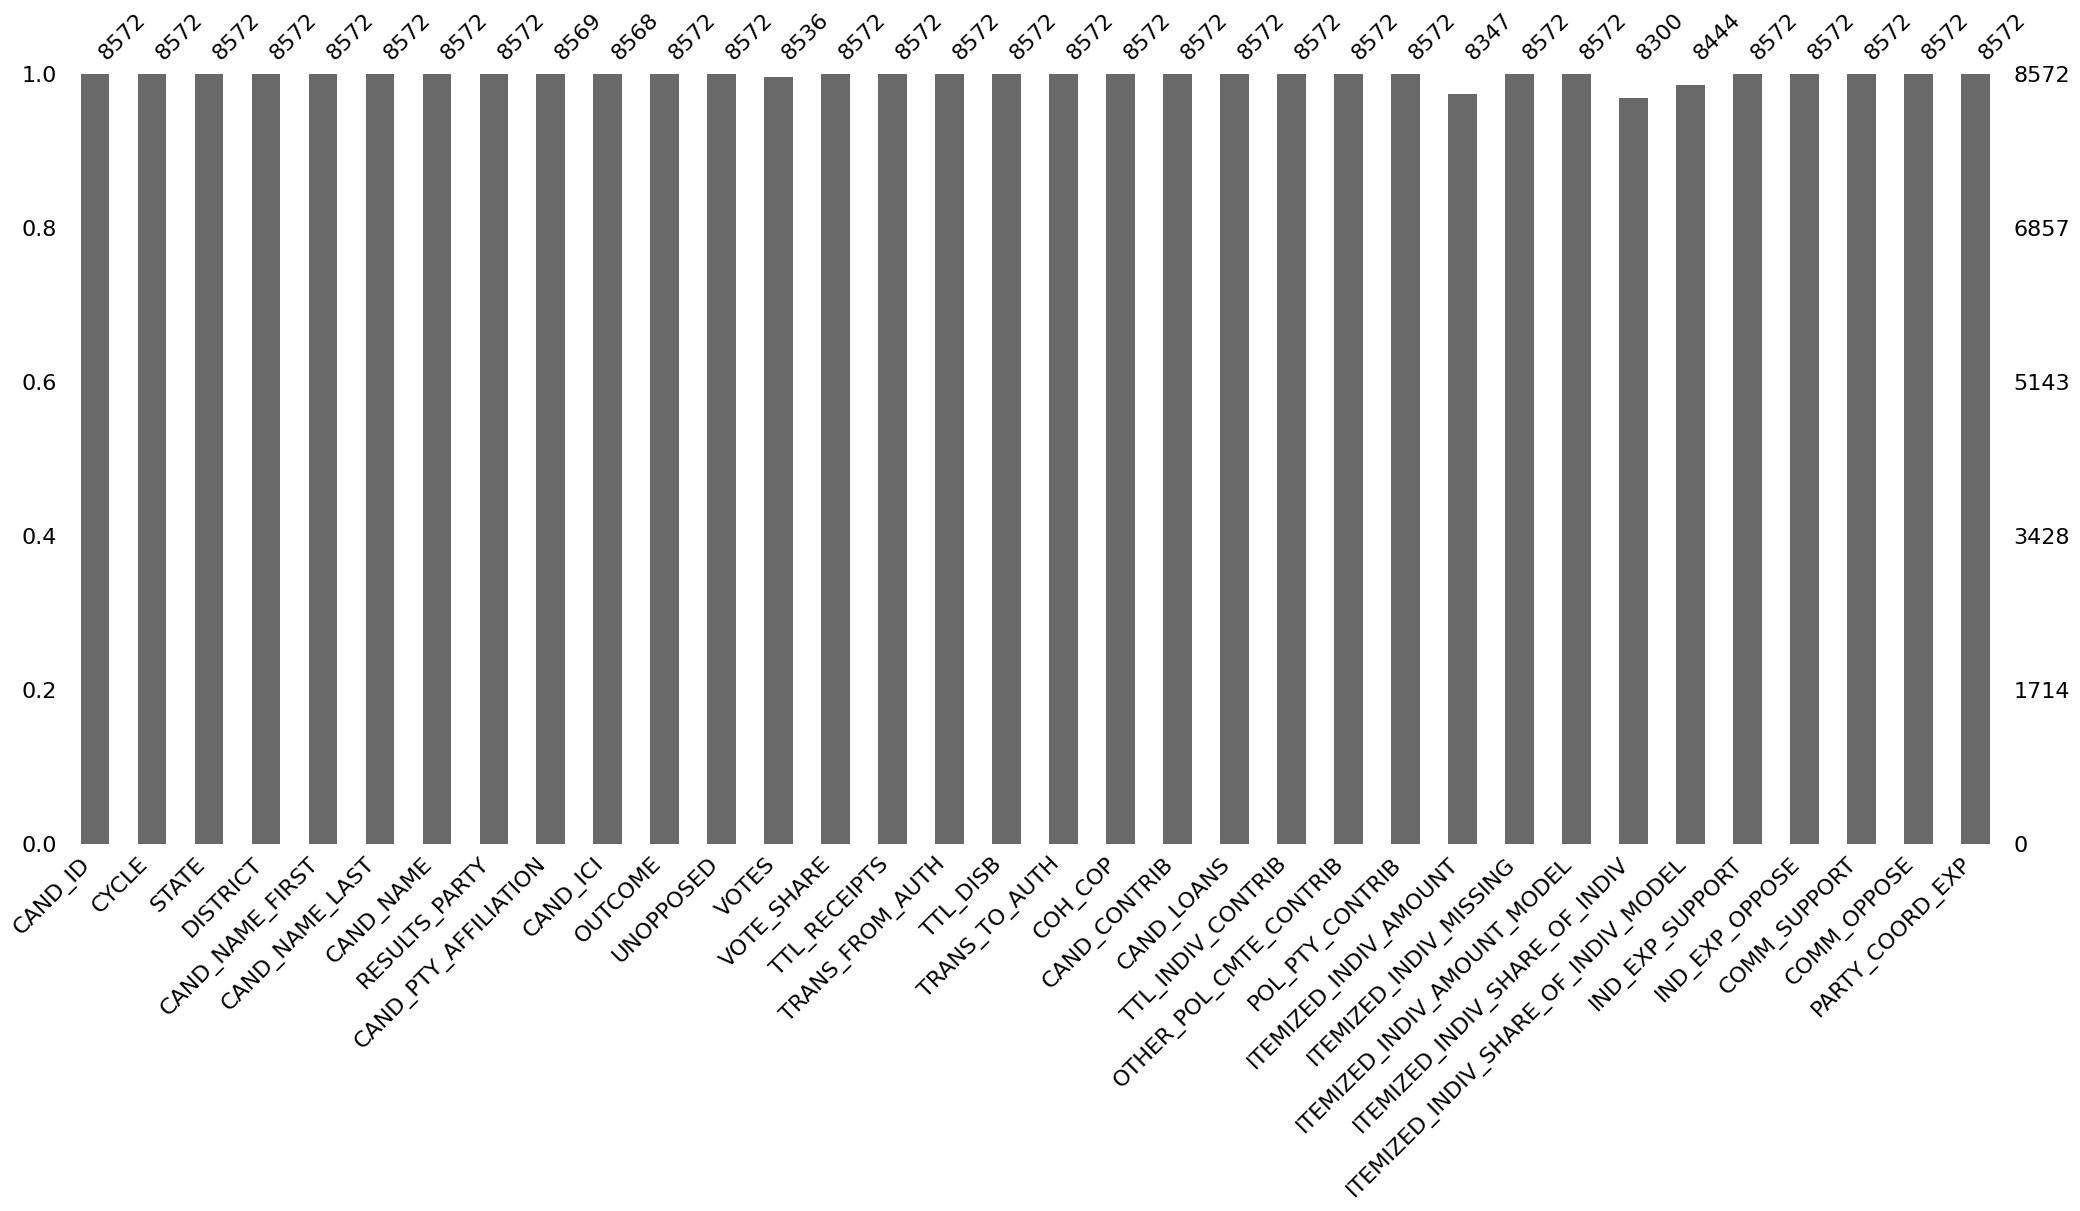

In [38]:
display(df.isna().sum())
msno.bar(df)    

In [39]:
print('Null incumbency: ')
display(df[df['CAND_ICI'].isna()])

df.loc[df.index[5158], 'CAND_ICI'] = 'C'
df.loc[df.index[5177], 'CAND_ICI'] = 'C'
df.loc[df.index[6539], 'CAND_ICI'] = 'C'
df.loc[df.index[6725], 'CAND_ICI'] = 'C'

print('Null incumbency afer manual correction: ')
display(df[df['CAND_ICI'].isna()])

Null incumbency: 


,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,ITEMIZED_INDIV_AMOUNT,ITEMIZED_INDIV_MISSING,ITEMIZED_INDIV_AMOUNT_MODEL,ITEMIZED_INDIV_SHARE_OF_INDIV,ITEMIZED_INDIV_SHARE_OF_INDIV_MODEL,IND_EXP_SUPPORT,IND_EXP_OPPOSE,COMM_SUPPORT,COMM_OPPOSE,PARTY_COORD_EXP
5158,H6AK00235,2016,AK,0,Steve,Lindbeck,"LINDBECK, STEVE",DEM,DEM,NaN,...,674766.0,0.0,674766.0,0.675170,0.675170,837.0,26.0,0.0,5001.0,192200.0
5177,H6AS00031,2016,AS,0,Vaitinasa Salu,Hunkin-Finau,"HUNKIN-FINAU, VAITINASA SALU",DEM,DEM,NaN,...,31955.0,0.0,31955.0,1.554610,1.554610,0.0,0.0,0.0,0.0,4872.0
6539,H6OH09073,2018,OH,1,Dirk,Kubala,"KUBALA, DIRK",LIB,LIB,NaN,...,510.0,0.0,510.0,0.728571,0.728571,5854635.0,1285232.0,0.0,4761.0,0.0
6725,H0TX27038,2018,TX,27,James,Duerr,"DUERR, JAMES MATTHEW",IND,REP,NaN,...,10650.0,0.0,10650.0,0.876760,0.876760,0.0,549804.0,0.0,0.0,0.0


Null incumbency afer manual correction: 


,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,ITEMIZED_INDIV_AMOUNT,ITEMIZED_INDIV_MISSING,ITEMIZED_INDIV_AMOUNT_MODEL,ITEMIZED_INDIV_SHARE_OF_INDIV,ITEMIZED_INDIV_SHARE_OF_INDIV_MODEL,IND_EXP_SUPPORT,IND_EXP_OPPOSE,COMM_SUPPORT,COMM_OPPOSE,PARTY_COORD_EXP


In [40]:
print('NaN votes: ', df['VOTES'].isna().sum())

df = df[df['UNOPPOSED']==False][df['VOTE_SHARE']<0.999]

print('NaN votes after dropping unopposed races: ', df['VOTES'].isna().sum())

df.reset_index(drop=True, inplace=True)

NaN votes:  36
NaN votes after dropping unopposed races:  0


In [41]:
print('Null party affiliation: ')
display(df[df['CAND_PTY_AFFILIATION'].isna()])

df.loc[df.index[1638], 'CAND_PTY_AFFILIATION'] = 'IND'
df.loc[df.index[1666], 'CAND_PTY_AFFILIATION'] = 'IND'
df.loc[df.index[2251], 'CAND_PTY_AFFILIATION'] = 'IND'

print('Null party affiliation instances after manual correction: ')
display(df[df['CAND_PTY_AFFILIATION'].isna()])

Null party affiliation: 


,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,ITEMIZED_INDIV_AMOUNT,ITEMIZED_INDIV_MISSING,ITEMIZED_INDIV_AMOUNT_MODEL,ITEMIZED_INDIV_SHARE_OF_INDIV,ITEMIZED_INDIV_SHARE_OF_INDIV_MODEL,IND_EXP_SUPPORT,IND_EXP_OPPOSE,COMM_SUPPORT,COMM_OPPOSE,PARTY_COORD_EXP
1602,H6WV01061,2006,WV,1,David,Moran,"MORAN, DAVID DUNSTAN",W,NaN,C,...,2495.0,0.0,2495.0,NaN,NaN,6412.0,46218.0,0.0,2585.0,0.0
1630,H8AZ01120,2008,AZ,1,Brent,Maupin,"MAUPIN, BRENT GEER",I,NaN,O,...,27967.0,0.0,27967.0,4.577250,4.577250,1034461.0,1073468.0,3253.0,62653.0,0.0
2206,H8OH15092,2008,OH,15,Don Elijah,Eckhart,"ECKHART, DON ELIJAH",I,NaN,C,...,33062.0,0.0,33062.0,11.974647,11.974647,2100164.0,1118394.0,4552.0,152523.0,0.0


Null party affiliation instances after manual correction: 


,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,ITEMIZED_INDIV_AMOUNT,ITEMIZED_INDIV_MISSING,ITEMIZED_INDIV_AMOUNT_MODEL,ITEMIZED_INDIV_SHARE_OF_INDIV,ITEMIZED_INDIV_SHARE_OF_INDIV_MODEL,IND_EXP_SUPPORT,IND_EXP_OPPOSE,COMM_SUPPORT,COMM_OPPOSE,PARTY_COORD_EXP
1602,H6WV01061,2006,WV,1,David,Moran,"MORAN, DAVID DUNSTAN",W,NaN,C,...,2495.0,0.0,2495.0,NaN,NaN,6412.0,46218.0,0.0,2585.0,0.0
1630,H8AZ01120,2008,AZ,1,Brent,Maupin,"MAUPIN, BRENT GEER",I,NaN,O,...,27967.0,0.0,27967.0,4.577250,4.577250,1034461.0,1073468.0,3253.0,62653.0,0.0
2206,H8OH15092,2008,OH,15,Don Elijah,Eckhart,"ECKHART, DON ELIJAH",I,NaN,C,...,33062.0,0.0,33062.0,11.974647,11.974647,2100164.0,1118394.0,4552.0,152523.0,0.0


In [42]:
df[df['ITEMIZED_INDIV_AMOUNT_MODEL'].isnull()]

,CAND_ID,CYCLE,STATE,DISTRICT,CAND_NAME_FIRST,CAND_NAME_LAST,CAND_NAME,RESULTS_PARTY,CAND_PTY_AFFILIATION,CAND_ICI,...,ITEMIZED_INDIV_AMOUNT,ITEMIZED_INDIV_MISSING,ITEMIZED_INDIV_AMOUNT_MODEL,ITEMIZED_INDIV_SHARE_OF_INDIV,ITEMIZED_INDIV_SHARE_OF_INDIV_MODEL,IND_EXP_SUPPORT,IND_EXP_OPPOSE,COMM_SUPPORT,COMM_OPPOSE,PARTY_COORD_EXP


In [43]:
df[['IND_EXP_SUPPORT', 'IND_EXP_OPPOSE', 'COMM_SUPPORT', 'COMM_OPPOSE']].eq(0).sum()

IND_EXP_SUPPORT    2876
IND_EXP_OPPOSE     3057
COMM_SUPPORT       4349
COMM_OPPOSE        4334
dtype: int64

In [44]:
df.columns = df.columns.str.lower()
df.rename(columns={"cand_ici": "incumbency"}, inplace=True)

numeric_cols = [
    "ttl_receipts",
    "ttl_disb",
    "coh_cop",
    "ttl_indiv_contrib",
    "other_pol_cmte_contrib",
    "pol_pty_contrib",
    "ind_exp_support",
    "ind_exp_oppose",
    "comm_support",
    "comm_oppose",
    "party_coord_exp",
    "itemized_indiv_amount_model",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["itemized_indiv_amount"] = pd.to_numeric(df["itemized_indiv_amount"], errors="coerce")
df["itemized_indiv_missing"] = pd.to_numeric(df["itemized_indiv_missing"], errors="coerce").fillna(0).astype(int)

receipts = df["ttl_receipts"].replace(0, np.nan)
indiv_contrib = df["ttl_indiv_contrib"].replace(0, np.nan)

df["log1p_ttl_receipts"] = np.log1p(df["ttl_receipts"])
df["burn_rate"] = df["ttl_disb"] / receipts
df["cash_ratio"] = df["coh_cop"] / receipts
df["indiv_share"] = df["ttl_indiv_contrib"] / receipts
df["other_cmte_share"] = df["other_pol_cmte_contrib"] / receipts
df["party_share"] = df["pol_pty_contrib"] / receipts

df["itemized_indiv_share"] = ( df["itemized_indiv_amount_model"] / indiv_contrib ).fillna(0)

df["total_outside_support"] = df["ind_exp_support"] + df["comm_support"]
df["total_outside_oppose"] = df["ind_exp_oppose"] + df["comm_oppose"]

df["log1p_total_outside_support"] = np.log1p(df["total_outside_support"].clip(lower=0))
df["log1p_total_outside_oppose"] = np.log1p(df["total_outside_oppose"].clip(lower=0))

df["has_party_coord_exp"] = (df["party_coord_exp"] > 0).astype(int)
df["log1p_party_coord_exp"] = np.log1p(df["party_coord_exp"].clip(lower=0))

In [45]:
derived_cols_regression = [
    "log1p_ttl_receipts",
    "burn_rate",
    "cash_ratio",
    "indiv_share",
    "other_cmte_share",
    "party_share",
    "log1p_total_outside_support",
    "log1p_total_outside_oppose",
    "has_party_coord_exp",
    "log1p_party_coord_exp",
    "itemized_indiv_share"
]

print(df[derived_cols_regression].isna().mean().sort_values())
print(df[derived_cols_regression].describe())

log1p_ttl_receipts             0.000000
log1p_total_outside_oppose     0.000000
log1p_total_outside_support    0.000000
has_party_coord_exp            0.000000
log1p_party_coord_exp          0.000000
itemized_indiv_share           0.000000
indiv_share                    0.005689
burn_rate                      0.005689
other_cmte_share               0.005689
party_share                    0.005689
cash_ratio                     0.005689
dtype: float64


       log1p_ttl_receipts    burn_rate   cash_ratio  indiv_share  \
count         8437.000000  8389.000000  8389.000000  8389.000000   
mean            12.830219     1.021831     0.300756     0.589650   
std              2.257642     3.824602     8.101471     0.370656   
min              0.000000    -0.046830    -4.138250     0.000000   
25%             11.514139     0.906298     0.005983     0.411391   
50%             13.668956     0.986121     0.041912     0.587187   
75%             14.331167     1.000131     0.247939     0.789645   
max             17.457315   333.866667   738.226667    25.800000   

       other_cmte_share  party_share  log1p_total_outside_support  \
count       8389.000000  8389.000000                  8437.000000   
mean           0.256634     0.010672                     6.936610   
std            0.236385     0.047353                     5.080949   
min            0.000000     0.000000                     0.000000   
25%            0.025378     0.000000      

In [46]:
weird = (df.loc[
        (df["burn_rate"] > 5) |
        (df["cash_ratio"] > 5) |
        (df["indiv_share"] > 1.5) |
        (df["other_cmte_share"] > 1.5) |
        (df["party_share"] > 1),
        ["cycle", "state", "district", "cand_id","ttl_receipts", "ttl_disb", "coh_cop","ttl_indiv_contrib", "other_pol_cmte_contrib", "pol_pty_contrib",
            "burn_rate", "cash_ratio", "indiv_share", "other_cmte_share", "party_share"]].copy())

flags = []
flags.append(np.where(weird["burn_rate"] > 5, "burn_rate>5", ""))
flags.append(np.where(weird["cash_ratio"] > 5, "cash_ratio>5", ""))
flags.append(np.where(weird["indiv_share"] > 1.5, "indiv_share>1.5", ""))
flags.append(np.where(weird["other_cmte_share"] > 1.5, "other_cmte_share>1.5", ""))
flags.append(np.where(weird["party_share"] > 1, "party_share>1", ""))

weird["flag_reason"] = [
    "; ".join(x for x in row if x)
    for row in zip(*flags)
]

weird = weird.sort_values(["cycle", "state", "district", "cand_id"]).round(3)

display(weird.head(50))
print(len(weird))
print('Null receipts: ', (df["ttl_receipts"] == 0).sum())

,cycle,state,district,cand_id,ttl_receipts,ttl_disb,coh_cop,ttl_indiv_contrib,other_pol_cmte_contrib,pol_pty_contrib,burn_rate,cash_ratio,indiv_share,other_cmte_share,party_share,flag_reason
111,2004,CA,48,H0CA47034,40.00,1994.00,0.00,40.00,0.00,0.0,49.850,0.000,1.000,0.000,0.0,burn_rate>5
185,2004,FL,21,H4FL21047,7208.00,12719.00,884.00,13437.00,0.00,0.0,1.765,0.123,1.864,0.000,0.0,indiv_share>1.5
1955,2008,MA,10,H2MA11060,117099.51,1217880.80,932910.63,33555.25,133048.02,0.0,10.400,7.967,0.287,1.136,0.0,burn_rate>5; cash_ratio>5
2755,2010,IN,6,H6IN06149,115.00,7603.91,0.00,115.00,0.00,0.0,66.121,0.000,1.000,0.000,0.0,burn_rate>5
3447,2012,CA,20,H8CA17089,100.00,6616.61,5607.72,0.00,0.00,100.0,66.166,56.077,0.000,0.000,1.0,burn_rate>5; cash_ratio>5
4206,2012,WA,9,H8WA09047,1818.00,6313.41,50174.78,1818.00,0.00,0.0,3.473,27.599,1.000,0.000,0.0,cash_ratio>5
4567,2014,LA,2,H2LA02107,250.00,4191.00,0.00,6450.00,0.00,0.0,16.764,0.000,25.800,0.000,0.0,burn_rate>5; indiv_share>1.5
4914,2014,TN,8,H2TN08077,1.50,500.80,1107.34,0.00,0.00,0.0,333.867,738.227,0.000,0.000,0.0,burn_rate>5; cash_ratio>5
5161,2016,CA,34,H6CA34229,20.00,1.80,518.20,20.00,0.00,0.0,0.090,25.910,1.000,0.000,0.0,cash_ratio>5
6331,2018,NJ,2,H8NJ02281,40.00,530.53,-165.53,40.00,0.00,0.0,13.263,-4.138,1.000,0.000,0.0,burn_rate>5


15
Null receipts:  48


In [47]:
# In light of the foregoing, in order to work with unambiguous derived features for each campaign, we must drop de minimis campaigns by a receipts threshold, namely $5000 USD
# This is justified in light of the following:
# 1) Very low-receipt campaigns create unstable finance ratios because the denominator is tiny

# 2) In electoral research, it is quite standard for analysts to restrict data to 'serious' contenders rather than treat all ballot-listed candidates as equally informative, 
# providing strong precedent (cf. Thomsen's Competition in Congressional Elections (https://www.cambridge.org/core/journals/american-political-science-review/article/competition-in-congressional-elections-money-versus-votes/F84C395D7155C9C0D82971BC0BFC75E8)
# and Sanbonmatsu & Gothreau's Money Matters in the Fifty States (https://cawp.rutgers.edu/sites/default/files/2021-12/money-matters-in-the-states_a11y.pdf))

# 3) In addition to the above, the $5,000 cutoff is in fact the FEC trigger at which federal candidate registration/reporting obligations attach, hence highly non-arbitrary

 
# Sensitivity check for to compare how many rows survive at $1000 versus $5000 

for floor in [1000, 5000]:
    n = (df["ttl_receipts"] >= floor).sum()
    pct = 100 * n / len(df)
    print(f"Number of observations with ttl_receipts >= ${floor:,.0f}: {n} rows ({pct:.2f}%)")
    
df_model = df.loc[df["ttl_receipts"] >= 5000]
df_model.isna().sum().sum()

Number of observations with ttl_receipts >= $1,000: 8308 rows (98.47%)
Number of observations with ttl_receipts >= $5,000: 8129 rows (96.35%)


np.int64(279)

### ITEMIZED INVIDUAL

In [48]:
display(df_model[df_model['itemized_indiv_share']< 0][['cand_id', 'cand_name', 'cycle', 'outcome', 'itemized_indiv_share', 'ttl_indiv_contrib', 'itemized_indiv_amount_model']])

# One observation has a negative itemized individual contribution aggregate, likely reflecting a refund/reversal or net adjustment. Since the composition
# proxy cannot have a negative itemized numerator, set it to zero rather than flipping the sign.

df_model.loc[df_model["itemized_indiv_amount"] < 0, "itemized_indiv_amount"] = 0
df_model.loc[df_model["itemized_indiv_amount_model"] < 0, "itemized_indiv_amount_model"] = 0

,cand_id,cand_name,cycle,outcome,itemized_indiv_share,ttl_indiv_contrib,itemized_indiv_amount_model
695,H2TX26127,"PAGE, GARY ROBERT",2004,0,-0.215983,7871.0,-1700.0


In [49]:
bad_indiv_rows = df_model.loc[ df_model["ttl_indiv_contrib"].le(0) & df_model["itemized_indiv_amount_model"].gt(0), 
                              [ "cand_id", "cycle", "state", "district", "cand_name", "ttl_receipts", "ttl_indiv_contrib", "itemized_indiv_amount", 
                               "itemized_indiv_amount_model", "itemized_indiv_share", "outcome", ], ].sort_values(["cycle", "state", "district"])

bad_indiv_rows

,cand_id,cycle,state,district,cand_name,ttl_receipts,ttl_indiv_contrib,itemized_indiv_amount,itemized_indiv_amount_model,itemized_indiv_share,outcome
346,H2MI01092,2004,MI,1,"HOOPER, DON",10497.00,0.0,4325.0,4325.0,0.0,0
619,H2PA19075,2004,PA,19,"SEARER, LESTER B",14370.00,0.0,14370.0,14370.0,0.0,0
737,H4VI00120,2004,VI,0,"MOSLER, WARREN BRUCE",330630.00,0.0,330630.0,330630.0,0.0,0
865,H6CA23198,2006,CA,23,"GARDNER, HARRY ARTHUR JR",5000.00,0.0,5000.0,5000.0,0.0,0
1312,H6NY14236,2006,NY,14,"MAIO, DANNIEL SUN",82425.00,0.0,44575.0,44575.0,0.0,0
1562,H4VI00120,2006,VI,0,"MOSLER, WARREN B",341126.50,0.0,341126.0,341126.0,0.0,0
1584,H4WI01064,2006,WI,1,"THOMAS, JEFFREY C",27972.00,0.0,20578.0,20578.0,0.0,0
2579,H0CO03108,2010,CO,3,"SEGREST, JAKE",18767.00,0.0,18766.0,18766.0,0.0,0
2643,H0FL14073,2010,FL,14,"ST CLAIRE, WILLIAM MAVERICK",8789.22,0.0,8774.0,8774.0,0.0,0
2657,H0FL20104,2010,FL,20,"BLUMENTHAL, STANLEY",274785.00,0.0,240720.0,240720.0,0.0,0


In [50]:
# A small number of marginal candidates have ttl_indiv_contrib reported as 0 even though itemized individual contributions account for nearly all receipts, the majority of which
# seem to be recording/reporting anomalies for which total receipts approximately equal itemized individual contributions, suggesting use of itemized_indiv_amount as a proxy for
# ttl_indiv_contrib

ratio = df_model["itemized_indiv_amount_model"] / df_model["ttl_receipts"].replace(0, np.nan)

mask_receipts_are_indiv = ( df_model["ttl_indiv_contrib"].le(0) & df_model["ttl_receipts"].gt(0) & df_model["itemized_indiv_amount_model"].gt(0) & ratio.between(0.8, 1.2) )

df_model.loc[mask_receipts_are_indiv, "ttl_indiv_contrib"] = df_model.loc[ mask_receipts_are_indiv, "ttl_receipts" ]

In [51]:
bad_indiv_rows = df_model.loc[ df_model["ttl_indiv_contrib"].le(0) & df_model["itemized_indiv_amount_model"].gt(0), 
                              [ "cand_id", "cycle", "state", "district", "cand_name", "ttl_receipts", "ttl_indiv_contrib", "itemized_indiv_amount", 
                               "itemized_indiv_amount_model", "itemized_indiv_share", "outcome", ], ].sort_values(["cycle", "state", "district"])

bad_indiv_rows

,cand_id,cycle,state,district,cand_name,ttl_receipts,ttl_indiv_contrib,itemized_indiv_amount,itemized_indiv_amount_model,itemized_indiv_share,outcome
346,H2MI01092,2004,MI,1,"HOOPER, DON",10497.00,0.0,4325.0,4325.0,0.0,0
1312,H6NY14236,2006,NY,14,"MAIO, DANNIEL SUN",82425.00,0.0,44575.0,44575.0,0.0,0
1584,H4WI01064,2006,WI,1,"THOMAS, JEFFREY C",27972.00,0.0,20578.0,20578.0,0.0,0
2772,H0KY02087,2010,KY,2,"MARKSBERRY, WARREN E",8253.34,0.0,4200.0,4200.0,0.0,0
2802,H0MA05090,2010,MA,5,"CLARK, ROBERT MICHAEL",14742.68,0.0,8928.0,8928.0,0.0,0
4458,H6FL17032,2014,FL,24,"NEREE, DUFIRSTSON JULIO",12040.00,0.0,1600.0,1600.0,0.0,0
7766,H2FL02140,2022,FL,3,"BROOKS, LINDA SUSAN MS.",131433.96,0.0,7093.0,7093.0,0.0,0


In [52]:
# Given the small number of pathological observations, we drop the remaining pathological rows containing nonzero itemized individual money in disproportion to total receipts
# and an errant zero or null entry for total individual contributions

df_model = df_model.loc[
    ~(
        df_model["ttl_indiv_contrib"].le(0)
        & df_model["itemized_indiv_amount_model"].gt(0)
    )
].copy()

df_model["itemized_indiv_share"] = (
    df_model["itemized_indiv_amount_model"]
    / df_model["ttl_indiv_contrib"].replace(0, np.nan)
).fillna(0)

bad_indiv_rows = df_model.loc[
    df_model["ttl_indiv_contrib"].le(0) & df_model["itemized_indiv_amount_model"].gt(0),
    [
        "cand_id",
        "cycle",
        "state",
        "district",
        "cand_name",
        "ttl_receipts",
        "ttl_indiv_contrib",
        "itemized_indiv_amount",
        "itemized_indiv_amount_model",
        "itemized_indiv_share",
        "outcome",
    ],
].sort_values(["cycle", "state", "district"])

bad_indiv_rows

,cand_id,cycle,state,district,cand_name,ttl_receipts,ttl_indiv_contrib,itemized_indiv_amount,itemized_indiv_amount_model,itemized_indiv_share,outcome


In [53]:
ratio_cols = [ "burn_rate", "cash_ratio", "indiv_share", "other_cmte_share", "party_share", ]

for col in ratio_cols:
    lo = df_model[col].quantile(0.01)
    hi = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(lower=lo, upper=hi)

print("Original rows:", len(df))
print("Model rows:", len(df_model))
print("Dropped rows:", len(df) - len(df_model))
print()
summary = (df_model[["log1p_ttl_receipts", "burn_rate", "cash_ratio","indiv_share", "other_cmte_share", "party_share"]].describe().T.rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "SD",
        "min": "Min",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Max"}).round(3))

summary

Original rows: 8437
Model rows: 8122
Dropped rows: 315



,N,Mean,SD,Min,Q1,Median,Q3,Max
log1p_ttl_receipts,8122.0,13.087,1.792,8.517,11.849,13.736,14.357,17.457
burn_rate,8122.0,0.952,0.160,0.417,0.908,0.986,1.000,1.506
cash_ratio,8122.0,0.191,0.313,-0.058,0.006,0.043,0.247,1.612
indiv_share,8122.0,0.587,0.241,0.015,0.415,0.586,0.785,1.000
other_cmte_share,8122.0,0.264,0.234,0.000,0.034,0.220,0.459,0.793
party_share,8122.0,0.008,0.027,0.000,0.000,0.000,0.003,0.186


In [54]:
print('Itemization amounts exceeding total indiv: ', df_model[df_model['itemized_indiv_amount_model'] > df_model['ttl_indiv_contrib']].shape[0])

mask_itemized_gt_indiv = (
    df_model["itemized_indiv_amount_model"] > df_model["ttl_indiv_contrib"]
)

df_model.loc[mask_itemized_gt_indiv, "ttl_indiv_contrib"] = df_model.loc[
    mask_itemized_gt_indiv,
    "itemized_indiv_amount_model"
]

df_model["itemized_indiv_share"] = (
    df_model["itemized_indiv_amount_model"]
    / df_model["ttl_indiv_contrib"].replace(0, np.nan)
).fillna(0)

Itemization amounts exceeding total indiv:  545


In [55]:
print('Itemization amounts exceeding total indiv after correction: ', df_model[df_model['itemized_indiv_amount'] > df_model['ttl_indiv_contrib']].shape[0])

print('Pathological intemized/indiv observations: ', df_model[df_model['itemized_indiv_share']>1].shape[0] + df_model[df_model['itemized_indiv_share']< 0].shape[0] )

Itemization amounts exceeding total indiv after correction:  0
Pathological intemized/indiv observations:  0


In [56]:
df_model.isna().sum().sum()

np.int64(265)

In [57]:
df_model[df_model['ttl_receipts']<5000]

,cand_id,cycle,state,district,cand_name_first,cand_name_last,cand_name,results_party,cand_pty_affiliation,incumbency,...,indiv_share,other_cmte_share,party_share,itemized_indiv_share,total_outside_support,total_outside_oppose,log1p_total_outside_support,log1p_total_outside_oppose,has_party_coord_exp,log1p_party_coord_exp


In [58]:
df_model[df_model['cand_pty_affiliation'] != df_model['results_party']]


,cand_id,cycle,state,district,cand_name_first,cand_name_last,cand_name,results_party,cand_pty_affiliation,incumbency,...,indiv_share,other_cmte_share,party_share,itemized_indiv_share,total_outside_support,total_outside_oppose,log1p_total_outside_support,log1p_total_outside_oppose,has_party_coord_exp,log1p_party_coord_exp
0,H6AK00045,2004,AK,0,Alvin A.,Anders,"YOUNG, DON E",LBT,REP,I,...,0.600552,0.374016,0.000158,0.963170,34266.0,0.0,10.441938,0.000000,0,0.000000
43,H4CA05232,2004,CA,5,Pat,Driscoll,"DRISCOLL, PATRICK WILLIAM",GRN,GRE,C,...,0.899587,0.015496,0.071455,0.397563,0.0,487.0,0.000000,6.190315,0,0.000000
54,H4CA11081,2004,CA,11,Gerald (Jerry) M.,McNerney,"MCNERNEY, GERALD MARK",W,DEM,C,...,0.877498,0.102684,0.000000,0.458228,43.0,608.0,3.784190,6.411818,0,0.000000
56,H4CA12071,2004,CA,12,Pat,Gray,"GRAY, PAT",GRN,GRE,C,...,0.827067,0.000000,0.031279,0.475821,0.0,596.0,0.000000,6.391917,0,0.000000
58,H4CA13079,2004,CA,13,George I.,Bruno,"BRUNO, GEORGE IR JR",REP,UNK,C,...,0.756881,0.158908,0.000000,0.565776,0.0,533.0,0.000000,6.280396,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8360,H4TX25083,2022,TX,38,Joel,DeJean,"DEJEAN, JOEL F.",IND,DEM,O,...,0.859033,0.000000,0.000000,1.000000,8.0,967283.0,2.197225,13.782247,0,0.000000
8364,H2UT02472,2022,UT,2,JayMac,McFarland,"MCFARLAND, JAY JAYMAC",UUP,OTH,C,...,1.000000,0.000000,0.000000,0.860383,0.0,276.0,0.000000,5.624018,0,0.000000
8369,H2UT04106,2022,UT,4,January,Walker,"WALKER, JANUARY",UUP,OTH,C,...,0.530275,0.000000,0.119236,0.693864,5000.0,183005.0,8.517393,12.117274,1,7.824446
8395,H2VT01100,2022,VT,0,Liam,Madden,"MADDEN, LIAM",REP,IND,O,...,1.000000,0.000000,0.000000,0.794274,0.0,1386810.0,0.000000,14.142517,0,0.000000


In [59]:
major = {"DEM", "REP"}

serious_party_mismatch = df_model[ df_model["results_party"].isin(major) & df_model["cand_pty_affiliation"].isin(major) & 
                                  (df_model["results_party"] != df_model["cand_pty_affiliation"]) ]

print(len(serious_party_mismatch))
print(serious_party_mismatch[["cycle", "state", "district", "cand_id", "cand_name", "results_party", "cand_pty_affiliation"]].sort_values(["cycle", "state", "district"])
      .head(50))

18
      cycle state  district    cand_id                   cand_name  \
1013   2006    HI         1  H6HI02301                  MENOR, RON   
1231   2006    NC         4  H6NC04128             ACUFF, STEVEN D   
1232   2006    NC         4  H6NC04037                PRICE, DAVID   
1618   2008    AL         5  H8AL05109       GRIFFITH, PARKER REP.   
2060   2008    NC         5  H6NC04037                PRICE, DAVID   
2098   2008    NJ         5  H8NJ05094           SHULMAN, DENNIS G   
3027   2010    NY         5  H0NY05062               MILANO, JAMES   
3875   2012    NJ         4  H8NJ04014       SMITH, CHRISTOPHER H.   
3876   2012    NJ         4  H2NJ04165           FROELICH, BRIAN P   
3917   2012    NY         5  H2NY05084        JENNINGS, ALLAN W JR   
6164   2018    KY         6  H8KY02098   SESSIONS, RANE EIR OLIVIA   
6475   2018    PA         3  H6PA01165                 LEIB, BRYAN   
7417   2020    TN         7  H0TN07255             SREEPADA, KIRAN   
7628   2022    CA

In [60]:
keep = {"DEM", "REP", "LIB", "GRN", "IND"}

df_model["party"] = np.where( df_model["results_party"].isin(keep), df_model["results_party"], "OTH" )

df_model.drop(columns=['cand_pty_affiliation', 'results_party'], inplace=True)

In [61]:
# final dedup!

keys = ["cand_id", "cycle", "state", "district"]

dups = df_model.duplicated(subset=keys, keep=False)

print(dups.sum())
print(df_model.loc[dups, keys].sort_values(keys).head(20))

0
Empty DataFrame
Columns: [cand_id, cycle, state, district]
Index: []


In [62]:
df_model.shape

(8122, 46)

In [63]:
df_model.columns

Index(['cand_id', 'cycle', 'state', 'district', 'cand_name_first',
       'cand_name_last', 'cand_name', 'incumbency', 'outcome', 'unopposed',
       'votes', 'vote_share', 'ttl_receipts', 'trans_from_auth', 'ttl_disb',
       'trans_to_auth', 'coh_cop', 'cand_contrib', 'cand_loans',
       'ttl_indiv_contrib', 'other_pol_cmte_contrib', 'pol_pty_contrib',
       'itemized_indiv_amount', 'itemized_indiv_missing',
       'itemized_indiv_amount_model', 'itemized_indiv_share_of_indiv',
       'itemized_indiv_share_of_indiv_model', 'ind_exp_support',
       'ind_exp_oppose', 'comm_support', 'comm_oppose', 'party_coord_exp',
       'log1p_ttl_receipts', 'burn_rate', 'cash_ratio', 'indiv_share',
       'other_cmte_share', 'party_share', 'itemized_indiv_share',
       'total_outside_support', 'total_outside_oppose',
       'log1p_total_outside_support', 'log1p_total_outside_oppose',
       'has_party_coord_exp', 'log1p_party_coord_exp', 'party'],
      dtype='str')

In [64]:
df_model[df_model['itemized_indiv_share']>1][['ttl_receipts','itemized_indiv_share','ttl_indiv_contrib' ]]

,ttl_receipts,itemized_indiv_share,ttl_indiv_contrib


In [65]:
analysis_cols = [
    'cand_id',
    'cycle',
    'state',
    'district',
    'cand_name',
    'party',
    'incumbency',
    'outcome',
    'unopposed',
    'votes',
    'vote_share',
    'ttl_receipts',
    'log1p_ttl_receipts',
    'coh_cop',
    'ttl_disb',
    'burn_rate',
    'cash_ratio',
    'indiv_share',
    'other_cmte_share',
    'party_share',
    'itemized_indiv_share',
    'total_outside_support',
    'total_outside_oppose',
    'log1p_total_outside_support',
    'log1p_total_outside_oppose',
    'has_party_coord_exp',
    'log1p_party_coord_exp',
    ]

df_model = df_model[analysis_cols]

In [68]:
df_model.isna().sum()

cand_id                        0
cycle                          0
state                          0
district                       0
cand_name                      0
party                          0
incumbency                     0
outcome                        0
unopposed                      0
votes                          0
vote_share                     0
ttl_receipts                   0
log1p_ttl_receipts             0
coh_cop                        0
ttl_disb                       0
burn_rate                      0
cash_ratio                     0
indiv_share                    0
other_cmte_share               0
party_share                    0
itemized_indiv_share           0
total_outside_support          0
total_outside_oppose           0
log1p_total_outside_support    0
log1p_total_outside_oppose     0
has_party_coord_exp            0
log1p_party_coord_exp          0
dtype: int64

In [66]:
df_model.to_parquet('house_clean.parquet', index=False)

In [67]:
df_model['itemized_indiv_share'].describe()

count    8122.000000
mean        0.764915
std         0.208918
min         0.000000
25%         0.665301
50%         0.826188
75%         0.916056
max         1.000000
Name: itemized_indiv_share, dtype: float64